## Sys.append("..")

- literally adds the string literal ".." to the list of folders python checks when resolving anm import
- it means "one level up from here" (Project Root)
```python
sys.append("..")
```

In [ ]:
#list all the paths Python will search for modules
for p in sys.path:
    print(p)

C:\Python312\python312.zip
C:\Python312\DLLs
C:\Python312\Lib
C:\Python312
c:\Users\mjhog\MyCode\fullstack-academy\agrichain_project\venv

c:\Users\mjhog\MyCode\fullstack-academy\agrichain_project\venv\Lib\site-packages
..


In [ ]:
# just for visualization, where we are ('here' is the current working directory)
import os

print(os.getcwd())


c:\Users\mjhog\MyCode\fullstack-academy\agrichain_project\notebooks


In [1]:
import sys
sys.path.append("..")
import pandas as pd
from src.data.load_data import load_complaints

train_df = load_complaints('train')
test_df = load_complaints('test')

train_df.shape, test_df.shape

((500, 11), (50, 11))

In [2]:
train_df.head()

,complaint_id,timestamp,customer_id,channel,complaint_text,category,priority,supplier_id,product_category,region,order_id
0,CMP-000001,2024-01-01 00:00:00,CUST-1228,email,Quality issue with order ORD-770487. The orang...,Damaged Goods,critical,SUP-5260,organic apples,Asia,ORD-770487
1,CMP-000002,2024-01-01 14:37:16,CUST-1476,email,Cannot get anyone to respond about order ORD-3...,Poor Communication,medium,SUP-11216,peaches,Asia,ORD-329258
2,CMP-000003,2024-01-02 05:14:32,CUST-1865,web,Order ORD-832052 is severely delayed. We neede...,Delivery Delay,low,SUP-7166,peaches,Asia,ORD-832052
3,CMP-000004,2024-01-02 19:51:49,CUST-1940,email,Shipment ORD-865179 stuck in transit for 10 da...,Delivery Delay,high,SUP-10417,oranges,Europe,ORD-865179
4,CMP-000005,2024-01-03 10:29:05,CUST-2751,app,Order ORD-183667 is incomplete. Missing 28 uni...,Missing Items,high,SUP-10749,limes,North America,ORD-183667


In [3]:
train_df['category'].value_counts()

category
Delivery Delay         138
Damaged Goods           89
Missing Items           80
Pricing Error           59
Service Complaint       38
Quality Issues          37
Poor Communication      34
Documentation Error     25
Name: count, dtype: int64

In [4]:
test_df['category'].value_counts()

category
Damaged Goods          14
Service Complaint       9
Delivery Delay          6
Documentation Error     6
Missing Items           5
Quality Issues          4
Poor Communication      3
Pricing Error           3
Name: count, dtype: int64

### Note
The train and test distributions don't match each other. In training, Delivery Delay was the single biggest category (27.6%) — but in the test set, it's tied for near-smallest (12%). Meanwhile Damaged Goods, which was only 17.8% of training, is the biggest chunk of the test set at 28%.

per-category metrics in Task 2 (precision/recall/F1 per category) are going to be based on very few examples

If the model gets 1 wrong out of 3, that category's recall drops to 66%, even if the model is actually pretty good — that's just what small numbers do statistically. It's not necessarily a sign of a bad model.



In [4]:
# len(train_df), len(test_df)
print(train_df.shape[0])
print(train_df.columns)
type(train_df.columns)

NameError: name 'train_df' is not defined

In [6]:
train_counts = train_df['category'].value_counts()
test_counts = test_df['category'].value_counts()

train_pct = (train_counts / len(train_df) * 100).round(1)
test_pct = (test_counts / len(test_df) * 100).round(1)

comparison = pd.DataFrame({
    'train_count': train_counts,    
    'test_count': test_counts,
    'train_pct': train_pct,
    'test_pct': test_pct
})

comparison.sort_values(by='test_pct', ascending=False)

,train_count,test_count,train_pct,test_pct
category,,,,
Damaged Goods,89,14,17.8,28.0
Service Complaint,38,9,7.6,18.0
Documentation Error,25,6,5.0,12.0
Delivery Delay,138,6,27.6,12.0
Missing Items,80,5,16.0,10.0
Quality Issues,37,4,7.4,8.0
Pricing Error,59,3,11.8,6.0
Poor Communication,34,3,6.8,6.0


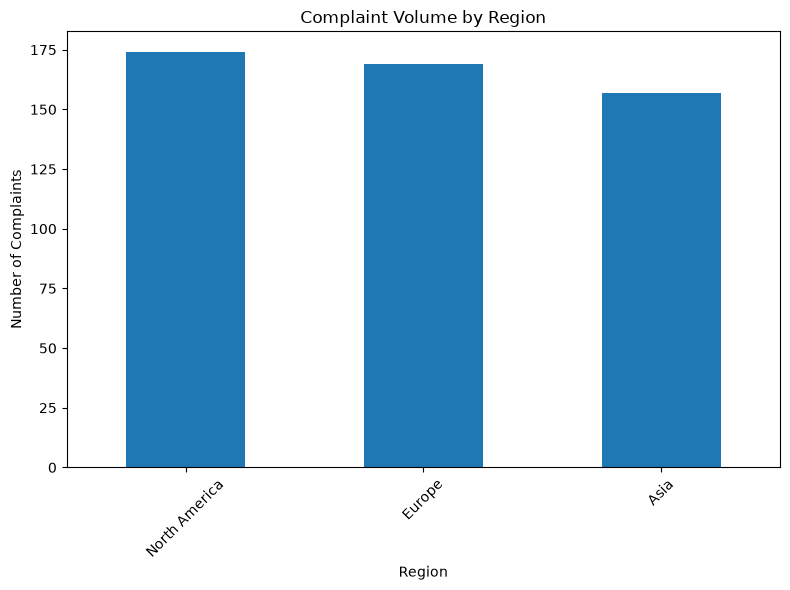

In [7]:
import matplotlib.pyplot as plt

region_counts = train_df["region"].value_counts()

plt.figure(figsize=(8, 6))
region_counts.plot(kind="bar")
plt.title("Complaint Volume by Region")
plt.xlabel("Region")
plt.ylabel("Number of Complaints")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Check:
total is 500, an even split would be ~167 each — and 160–175 is right in that range. That's useful: region isn't a source of imbalance or bias risk the way category was.

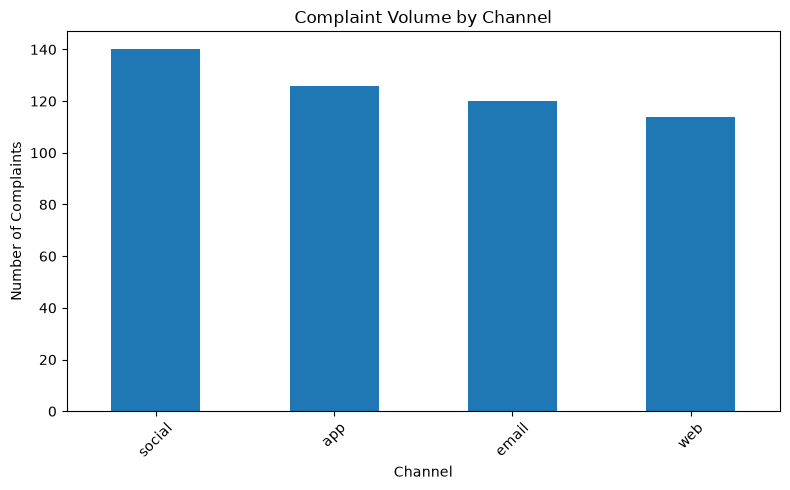

In [8]:
channel_counts = train_df["channel"].value_counts()

plt.figure(figsize=(8, 5))
channel_counts.plot(kind="bar")
plt.title("Complaint Volume by Channel")
plt.xlabel("Channel")
plt.ylabel("Number of Complaints")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

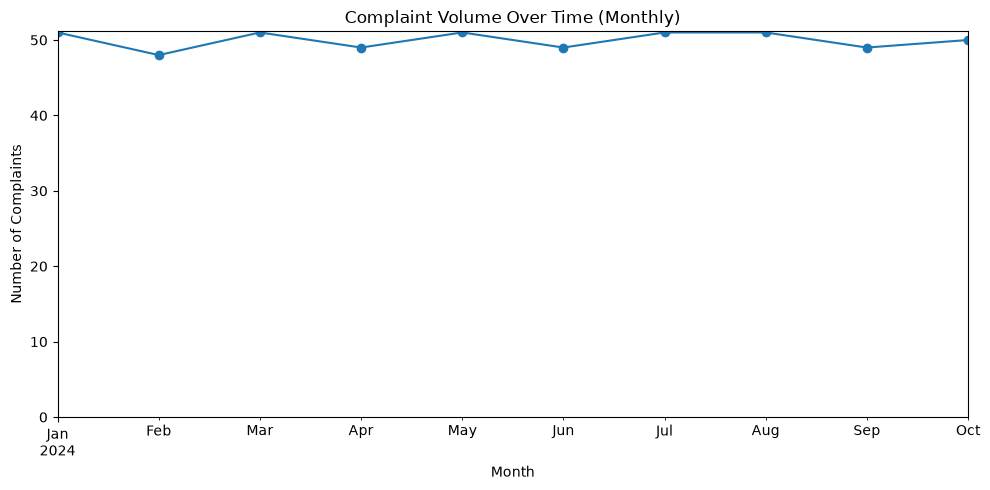

In [9]:
# Group complaints by month and count them
monthly_counts = train_df.set_index("timestamp").resample("ME").size()

plt.figure(figsize=(10, 5))
monthly_counts.plot(kind="line", marker="o")
plt.title("Complaint Volume Over Time (Monthly)")
plt.xlabel("Month")
plt.ylabel("Number of Complaints")
plt.ylim(
    bottom=0
)  # <-- forces the y-axis to start at 0 otherwise its misleading professionals call it a truncated y-axis,
plt.tight_layout()
plt.show()

### check:
complaint volume is remarkably stable month-to-month, roughly 48-51 per month, no meaningful growth or decline trend, no obvious seasonal spike.

## What we've actually confirmed so far in task1_data_analysis.ipynb

1. **Category imbalance in training data** — 8 categories, ranging from 138 examples (Delivery Delay) down to 25 (Documentation Error), a 5.5x ratio. This is a real imbalance issue for Task 2's model training, not just a test-set problem.
2. **Train/test distribution mismatch**— because the split wasn't stratified, train and test disagree on which categories are "common." Combined with a small 50-row test set, some categories have as few as 3 test examples — meaning per-category metrics (precision/recall/F1) should be interpreted cautiously in Task 2, not treated as fully reliable.
3. **Region** — roughly even (160-175 per region out of ~500), no imbalance concern.
4. **Channel**— roughly even (114-140 per channel), social slightly ahead but not dramatically.
5. **Time (monthly)** — flat, no real trend or seasonality once we corrected the misleading auto-scaled y-axis; complaint volume sits steadily around 48-51/month.

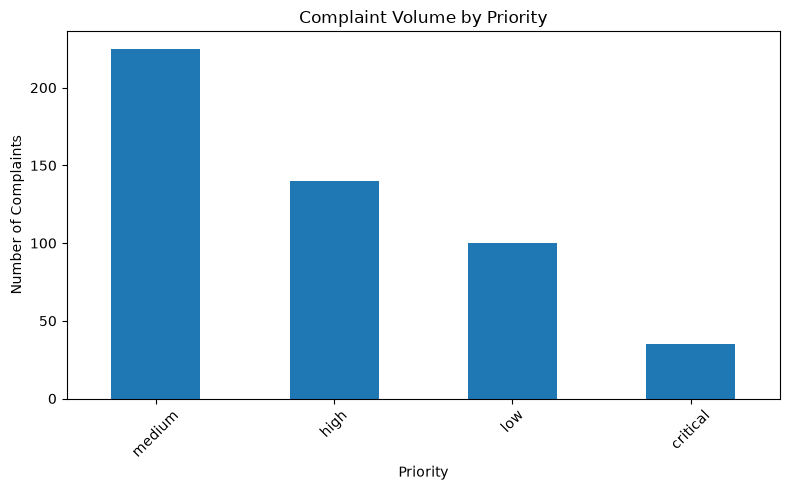

In [10]:
priority_counts = train_df["priority"].value_counts()

plt.figure(figsize=(8, 5))
priority_counts.plot(kind="bar")
plt.title("Complaint Volume by Priority")
plt.xlabel("Priority")
plt.ylabel("Number of Complaints")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [11]:
priority_by_category = (
    pd.crosstab(train_df["category"], train_df["priority"], normalize="index") * 100
)
priority_by_category.round(1)

priority,critical,high,low,medium
category,,,,
Damaged Goods,14.6,43.8,10.1,31.5
Delivery Delay,5.8,27.5,21.0,45.7
Documentation Error,0.0,8.0,32.0,60.0
Missing Items,1.2,20.0,17.5,61.3
Poor Communication,2.9,14.7,41.2,41.2
Pricing Error,5.1,13.6,30.5,50.8
Quality Issues,21.6,51.4,5.4,21.6
Service Complaint,2.6,34.2,15.8,47.4


## Priority 
### Not random, correlated with category:
- **Quality Issues** skews high/critical (51.4% high, 21.6% critical) — most severe category
- **Documentation Error and Missing Items** skew low/medium, 0–1.2% critical
- Implication: category is a useful

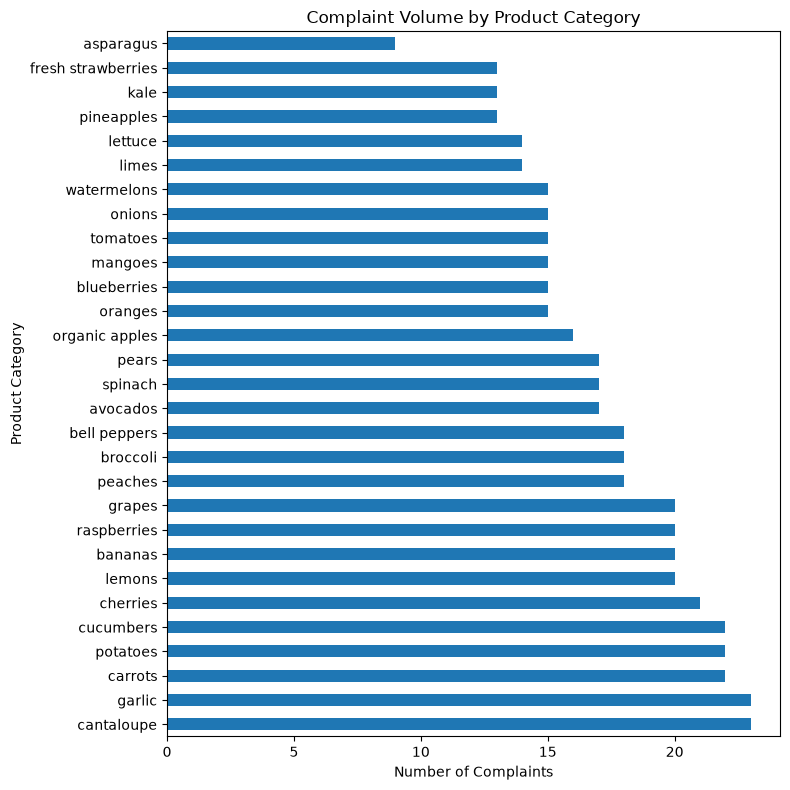

In [12]:
product_counts = train_df["product_category"].value_counts()

plt.figure(figsize=(8, 8))
product_counts.plot(kind="barh")
plt.title("Complaint Volume by Product Category")
plt.xlabel("Number of Complaints")
plt.ylabel("Product Category")
plt.tight_layout()
plt.show()

In [13]:
from src.data.preprocess_text import normalize_text, remove_stopwords

train_df["complaint_text_normalized"] = train_df["complaint_text"].apply(normalize_text)
train_df["complaint_text_no_stopwords"] = train_df["complaint_text_normalized"].apply(
    remove_stopwords
)

# Sanity check on a few real rows before trusting it across all 500
train_df[
    ["complaint_text", "complaint_text_normalized", "complaint_text_no_stopwords"]
].sample(5, random_state=1)

,complaint_text,complaint_text_normalized,complaint_text_no_stopwords
304,Invoice ORD-202170 shows incorrect pricing. We...,invoice ord202170 shows incorrect pricing we w...,invoice ord202170 shows incorrect pricing quot...
340,Quality control failure on order ORD-370804. r...,quality control failure on order ord370804 ras...,quality control failure order ord370804 raspbe...
47,No response to my emails about order ORD-82416...,no response to my emails about order ord824161...,response emails order ord824161 ive trying rea...
67,Poor service experience with shipment ORD-5838...,poor service experience with shipment ord58386...,poor service experience shipment ord583863 sta...
479,Delivery delay for shipment ORD-748410. Expect...,delivery delay for shipment ord748410 expected...,delivery delay shipment ord748410 expected 202...


In [14]:
test_df["complaint_text_normalized"] = test_df["complaint_text"].apply(normalize_text)
test_df["complaint_text_no_stopwords"] = test_df["complaint_text_normalized"].apply(
    remove_stopwords
)

test_df[
    ["complaint_text", "complaint_text_normalized", "complaint_text_no_stopwords"]
].sample(5, random_state=1)

,complaint_text,complaint_text_normalized,complaint_text_no_stopwords
27,Service quality is deteriorating. Multiple iss...,service quality is deteriorating multiple issu...,service quality deteriorating multiple issues ...
35,Shipment ORD-272117 arrived with crushed boxes...,shipment ord272117 arrived with crushed boxes ...,shipment ord272117 arrived crushed boxes multi...
40,Quality of watermelons in order ORD-700350 is ...,quality of watermelons in order ord700350 is s...,quality watermelons order ord700350 substandar...
38,Shipment ORD-793360 arrived with crushed boxes...,shipment ord793360 arrived with crushed boxes ...,shipment ord793360 arrived crushed boxes multi...
2,Quality of mangoes in order ORD-463541 is subs...,quality of mangoes in order ord463541 is subst...,quality mangoes order ord463541 substandard it...


In [ ]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()

# fit_transform does two things at once: LEARNS the mapping from your
# training categories (fit), then converts them to numbers (transform)
train_df["category_encoded"] = label_encoder.fit_transform(train_df["category"])

# For test data, only TRANSFORM - never fit again. We must reuse the exact
# same mapping learned from training, or "Delivery Delay" could end up
# meaning a different number in test than it did in train.
test_df["category_encoded"] = label_encoder.transform(test_df["category"])

i = 0
for label in label_encoder.classes_:
    print(f"{i}: {label}")
    i += 1

0: Damaged Goods
1: Delivery Delay
2: Documentation Error
3: Missing Items
4: Poor Communication
5: Pricing Error
6: Quality Issues
7: Service Complaint


In [22]:
print()
train_df[["category", "category_encoded"]].sample(8, random_state=1)

,category,category_encoded
304,Pricing Error,5
340,Quality Issues,6
47,Poor Communication,4
67,Service Complaint,7
479,Delivery Delay,1
485,Missing Items,3
310,Delivery Delay,1
31,Quality Issues,6


In [20]:
print(label_encoder.classes_)

['Damaged Goods' 'Delivery Delay' 'Documentation Error' 'Missing Items'
 'Poor Communication' 'Pricing Error' 'Quality Issues' 'Service Complaint']


### Why the trailing underscore `(classes_)`

Small but useful scikit-learn convention, any attribute ending in an underscore means "this value only exists after you've called .fit() — 
**it's something the model learned, not something you set yourself** 

### Balance dataset

Since duplicating/oversampling minority categories risks memorization on a small dataset, we're using class weights — telling the model "a mistake on a rare category costs more than a mistake on a common one," without touching the actual data.
```python
weight for class i = total_samples / (num_classes × count_of_class_i)
```
**Delivery Delay** (138 examples) gets a low weight (~0.45), because it's common — the formula divides by a big number.
- Delivery Delay: 138 examples × 0.45 weight ≈ 62
- Documentation Error: 25 examples × 2.50 weight ≈ 62.5

so the count x weight ends up roughly equal, which is the intended effect.

as for "balanced" argumment, its the sensible choice, since the other option is custom weights

In [ ]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

class_weights = compute_class_weight(
    class_weight="balanced",
    # np.unique returns an arry of the unique values in the input array, which is what compute_class_weight expects
    # instead of the similar looking pandas Series.unique() method, which returns a pandas Series instead of a numpy array
    classes=np.unique(train_df["category_encoded"]),
    # raw data, where the counting happens
    y=train_df["category_encoded"],
)

# Keras expects class weights as a dictionary: {0: weight, 1: weight, ...}
# zip pairs them up, dict creates a dictionary from the pairs (label_num, weight))
class_weight_dict = dict(zip(np.unique(train_df["category_encoded"]), class_weights))

for label_num, weight in class_weight_dict.items():
    category_name = label_encoder.classes_[label_num]
    print(f"{category_name} ({label_num}): weight = {weight:.2f}")

Damaged Goods (0): weight = 0.70
Delivery Delay (1): weight = 0.45
Documentation Error (2): weight = 2.50
Missing Items (3): weight = 0.78
Poor Communication (4): weight = 1.84
Pricing Error (5): weight = 1.06
Quality Issues (6): weight = 1.69
Service Complaint (7): weight = 1.64


`zip()` takes two (or more) separate lists/arrays and pairs them up, position by position — first item with first item, second with second, and so on
it creates a sequence of pairs (tuples)

`enumerate()` hands you (index, value) pairs; `.items()` hands you (key, value) pairs. Same underlying mechanic, different source.

### python note:
```python
for key, value, in iterable
```
its like destructuring in js

### Note:
- **Delivery Delay** (most common category, 138 examples) got the lowest weight (0.45) 
- **Documentation Error** (rarest, 25 examples) got the highest weight (2.50)

In [17]:
train_df.head(5)

,complaint_id,timestamp,customer_id,channel,complaint_text,category,priority,supplier_id,product_category,region,order_id,complaint_text_normalized,complaint_text_no_stopwords,category_encoded
0,CMP-000001,2024-01-01 00:00:00,CUST-1228,email,Quality issue with order ORD-770487. The orang...,Damaged Goods,critical,SUP-5260,organic apples,Asia,ORD-770487,quality issue with order ord770487 the oranges...,quality issue order ord770487 oranges show sig...,0
1,CMP-000002,2024-01-01 14:37:16,CUST-1476,email,Cannot get anyone to respond about order ORD-3...,Poor Communication,medium,SUP-11216,peaches,Asia,ORD-329258,cannot get anyone to respond about order ord32...,cannot get anyone respond order ord329258 dela...,4
2,CMP-000003,2024-01-02 05:14:32,CUST-1865,web,Order ORD-832052 is severely delayed. We neede...,Delivery Delay,low,SUP-7166,peaches,Asia,ORD-832052,order ord832052 is severely delayed we needed ...,order ord832052 severely delayed needed bell p...,1
3,CMP-000004,2024-01-02 19:51:49,CUST-1940,email,Shipment ORD-865179 stuck in transit for 10 da...,Delivery Delay,high,SUP-10417,oranges,Europe,ORD-865179,shipment ord865179 stuck in transit for 10 day...,shipment ord865179 stuck transit 10 days causi...,1
4,CMP-000005,2024-01-03 10:29:05,CUST-2751,app,Order ORD-183667 is incomplete. Missing 28 uni...,Missing Items,high,SUP-10749,limes,North America,ORD-183667,order ord183667 is incomplete missing 28 units...,order ord183667 incomplete missing 28 units ra...,3


### Save: 
**Save processed DataFrames** as organized files so I dont have to rerun this notebook every time I exit and come back (data/processed)

In [18]:
train_df.to_csv("../data/processed/train_processed.csv", index=False)
# index=False means we don't want to save the row numbers (0, 1, 2, ...) as a separate column in the CSV file.
test_df.to_csv("../data/processed/test_processed.csv", index=False)

print("Saved train shape:", train_df.shape)
print("Saved test shape:", test_df.shape)

Saved train shape: (500, 14)
Saved test shape: (50, 14)


In [ ]:
import pickle
# save the label encoder and class weights to disk so we can use them later in the model training and inference
with open("../models/label_encoder.pkl", "wb") as f:    
    pickle.dump(label_encoder, f)

with open("../models/class_weights.pkl", "wb") as f:
    pickle.dump(class_weight_dict, f)

print("Saved encoder and class weights.")

Saved encoder and class weights.


### why we need pickle
- `train_df` and `test_df` are **DataFrames** — fundamentally tabular data.

- `label_encoder` and ```class_weight_dict``` are not tabular data at all. One is a Python dictionary (key-value pairs, {0: 0.70, 1: 0.45, ...}) — not rows and columns. The other is a LabelEncoder object — an instance of a class, with internal attributes like .classes_ sitting inside it